# Combined Pipeline Evaluation: 3-Class Pneumonia Classifier

**Classes:**
- `0` → NORMAL
- `1` → BACTERIAL PNEUMONIA  
- `2` → VIRAL PNEUMONIA

**Pipeline logic:**
1. Phase 1 model predicts NORMAL (0) vs PNEUMONIA (1)
2. If PNEUMONIA → Phase 2 predicts BACTERIAL (0) vs VIRAL (1)
3. Combined output: NORMAL / BACTERIAL / VIRAL

In [13]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_curve, auc, ConfusionMatrixDisplay
)
from sklearn.preprocessing import label_binarize
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 1. Model Definitions

In [14]:
def build_phase1_model():
    """NORMAL vs PNEUMONIA — matches Phase_1_Classifier architecture."""
    return nn.Sequential(
        nn.Linear(1024, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, 64),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(64, 1)
    )

def build_phase2_model():
    """BACTERIAL vs VIRAL — matches Phase_2_Classifier architecture."""

    return nn.Sequential(
    nn.Linear(1024, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.5),

    nn.Linear(256, 64),
    nn.BatchNorm1d(64),
    nn.ReLU(),
    nn.Dropout(0.4),

    nn.Linear(64, 1)
)

# ── Load weights ──────────────────────────────────────────────────────────────
PHASE1_MODEL_PATH = "model_repository/pneumonia_model_phase_1.pth"
PHASE2_MODEL_PATH = "model_repository/pneumonia_model_phase_2.pth"

# Thresholds tuned from ROC (Youden J) in your individual notebooks
PHASE1_THRESHOLD = 0.7904277   # from Phase 1 notebook
PHASE2_THRESHOLD = 0.41026464  # from Phase 2 notebook

phase1_model = build_phase1_model().to(device)
phase1_model.load_state_dict(torch.load(PHASE1_MODEL_PATH, map_location=device))
phase1_model.eval()

phase2_model = build_phase2_model().to(device)
phase2_model.load_state_dict(torch.load(PHASE2_MODEL_PATH, map_location=device))
phase2_model.eval()

print("Models loaded successfully.")

Models loaded successfully.


## 2. Load Test Data

We need a combined test set where each sample has:
- 1024 feature columns (DenseNet121 embeddings)
- A 3-class label: **0 = NORMAL, 1 = BACTERIAL, 2 = VIRAL**

### Option A — Build from existing CSVs (recommended)
Phase 1 test CSV has labels `0=NORMAL, 1=PNEUMONIA`.  
Phase 2 test CSV (pneumonia-only) has labels `0=BACTERIAL, 1=VIRAL`.  
We merge them to create the unified 3-class test set.

In [15]:
# ── Phase 1 test CSV: label 0=NORMAL, 1=PNEUMONIA ────────────────────────────
p1_test = pd.read_csv("Phase_1_Classifier/data/test.csv")

# ── Phase 2 test CSV: label 0=BACTERIAL, 1=VIRAL (pneumonia only) ────────────
p2_test = pd.read_csv("Phase_2_Classifier/data/test.csv")

# Separate NORMAL rows from Phase 1 (they have label 0)
normal_rows = p1_test[p1_test["label"] == 0].copy()
normal_rows["combined_label"] = 0   # NORMAL

pneumonia_rows = p2_test.copy()
pneumonia_rows["combined_label"] = pneumonia_rows["label"].map({0: 1, 1: 2})

# Stack: keep only feature columns + combined_label
feat_cols = [c for c in p1_test.columns if c != "label"]

normal_part     = normal_rows[feat_cols + ["combined_label"]]
pneumonia_part  = pneumonia_rows[feat_cols + ["combined_label"]]

combined_test = pd.concat([normal_part, pneumonia_part], ignore_index=True)
combined_test = combined_test.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle

print(f"Combined test set shape: {combined_test.shape}")
print(combined_test["combined_label"].value_counts().rename({0:"NORMAL",1:"BACTERIAL",2:"VIRAL"}))

Combined test set shape: (783, 1025)
combined_label
BACTERIAL    380
VIRAL        202
NORMAL       201
Name: count, dtype: int64


## 3. Run the Combined Pipeline

For each sample:
1. Feed features into Phase 1 → get P(pneumonia)
2. If predicted NORMAL → final class = 0
3. Else → feed same features into Phase 2 → get P(viral)
4. Map to final class: BACTERIAL=1, VIRAL=2

In [16]:
X_test = combined_test[feat_cols].values
y_true = combined_test["combined_label"].values

X_tensor = torch.tensor(X_test, dtype=torch.float32)
dataset  = TensorDataset(X_tensor)
loader   = DataLoader(dataset, batch_size=64, shuffle=False)

p1_probs_all = []
p2_probs_all = []
y_pred_all   = []

with torch.no_grad():
    for (batch,) in loader:
        batch = batch.to(device)

        # Phase 1
        p1_logits = phase1_model(batch).squeeze(1)
        p1_probs  = torch.sigmoid(p1_logits).cpu().numpy()
        p1_preds  = (p1_probs >= PHASE1_THRESHOLD).astype(int)  # 0=NORMAL, 1=PNEUMONIA

        # Phase 2 (run for ALL samples; we'll mask the result below)
        p2_logits = phase2_model(batch).squeeze(1)
        p2_probs  = torch.sigmoid(p2_logits).cpu().numpy()
        p2_preds  = (p2_probs >= PHASE2_THRESHOLD).astype(int)  # 0=BACTERIAL, 1=VIRAL

        # Combine
        # p1 pred=0 → NORMAL (0)
        # p1 pred=1 & p2 pred=0 → BACTERIAL (1)
        # p1 pred=1 & p2 pred=1 → VIRAL (2)
        batch_preds = np.where(p1_preds == 0, 0,
                      np.where(p2_preds == 0, 1, 2))

        p1_probs_all.append(p1_probs)
        p2_probs_all.append(p2_probs)
        y_pred_all.append(batch_preds)

p1_probs_all = np.concatenate(p1_probs_all)
p2_probs_all = np.concatenate(p2_probs_all)
y_pred       = np.concatenate(y_pred_all)

print("Prediction distribution:")
unique, counts = np.unique(y_pred, return_counts=True)
label_map = {0: "NORMAL", 1: "BACTERIAL", 2: "VIRAL"}
for u, c in zip(unique, counts):
    print(f"  {label_map[u]}: {c}")

Prediction distribution:
  NORMAL: 213
  BACTERIAL: 356
  VIRAL: 214


## 4. Classification Metrics

In [17]:
CLASS_NAMES = ["NORMAL", "BACTERIAL", "VIRAL"]

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
rec  = recall_score(y_true, y_pred, average="macro", zero_division=0)
f1   = f1_score(y_true, y_pred, average="macro", zero_division=0)

print("=" * 45)
print("  COMBINED PIPELINE — OVERALL METRICS")
print("=" * 45)
print(f"  Accuracy          : {acc:.4f}")
print(f"  Precision (macro) : {prec:.4f}")
print(f"  Recall    (macro) : {rec:.4f}")
print(f"  F1 Score  (macro) : {f1:.4f}")
print("=" * 45)
print()
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

  COMBINED PIPELINE — OVERALL METRICS
  Accuracy          : 0.8148
  Precision (macro) : 0.8095
  Recall    (macro) : 0.8233
  F1 Score  (macro) : 0.8157

              precision    recall  f1-score   support

      NORMAL       0.94      1.00      0.97       201
   BACTERIAL       0.84      0.79      0.81       380
       VIRAL       0.65      0.69      0.67       202

    accuracy                           0.81       783
   macro avg       0.81      0.82      0.82       783
weighted avg       0.82      0.81      0.81       783



## 5. Confusion Matrix

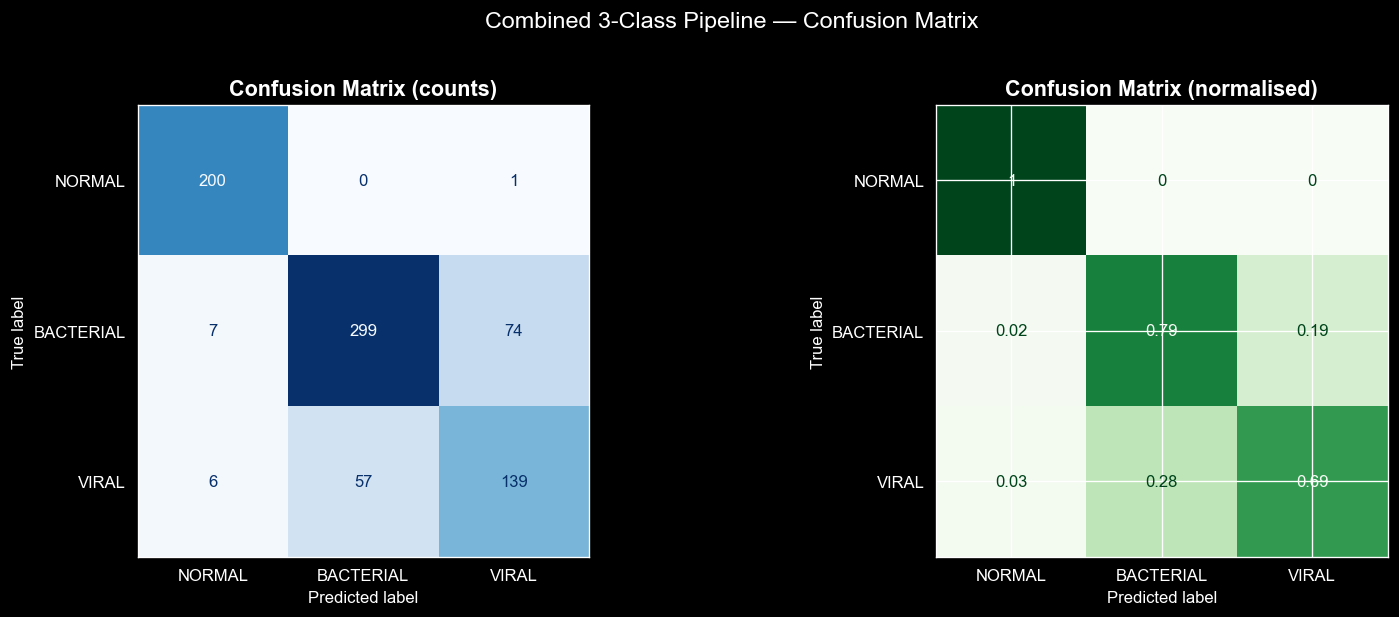

Saved: confusion_matrix_combined.png


In [18]:
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
disp_counts = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp_counts.plot(cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix (counts)", fontsize=13, fontweight="bold")

# Normalised (row = true class)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp_norm = ConfusionMatrixDisplay(confusion_matrix=np.round(cm_norm, 2), display_labels=CLASS_NAMES)
disp_norm.plot(cmap="Greens", ax=axes[1], colorbar=False)
axes[1].set_title("Confusion Matrix (normalised)", fontsize=13, fontweight="bold")
axes[0].grid(False)

plt.suptitle("Combined 3-Class Pipeline — Confusion Matrix", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("confusion_matrix_combined.png", bbox_inches="tight")
plt.show()
print("Saved: confusion_matrix_combined.png")

## 6. ROC Curves (One-vs-Rest)

We build class probability estimates from the two-stage pipeline:

| Class | Probability estimate |
|-------|---------------------|
| NORMAL | `1 - P1` (phase 1 says NOT pneumonia) |
| BACTERIAL | `P1 × (1 - P2)` (pneumonia AND not viral) |
| VIRAL | `P1 × P2` (pneumonia AND viral) |

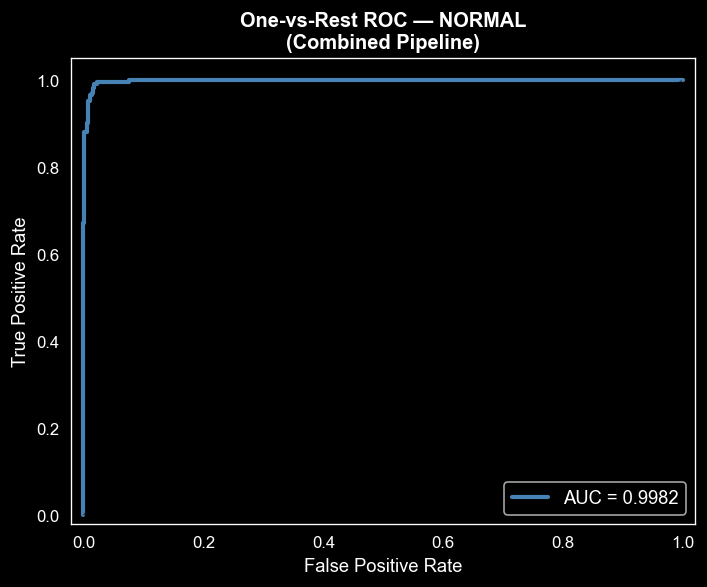

Saved: roc_curve_normal.png


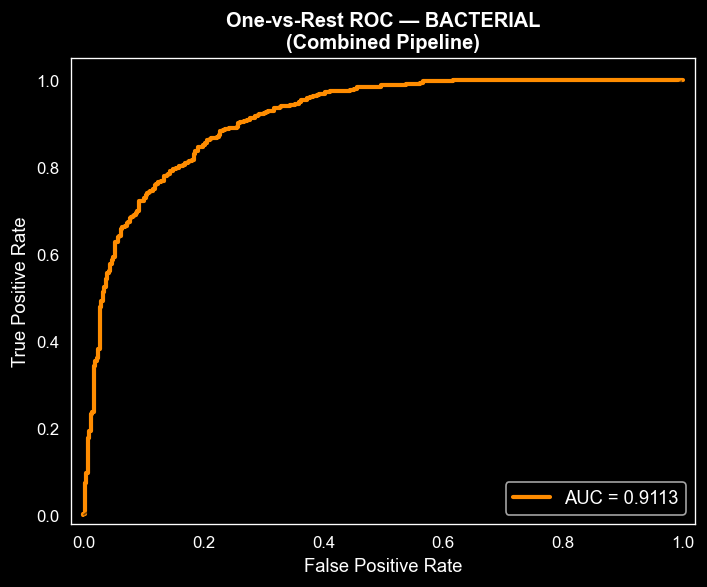

Saved: roc_curve_bacterial.png


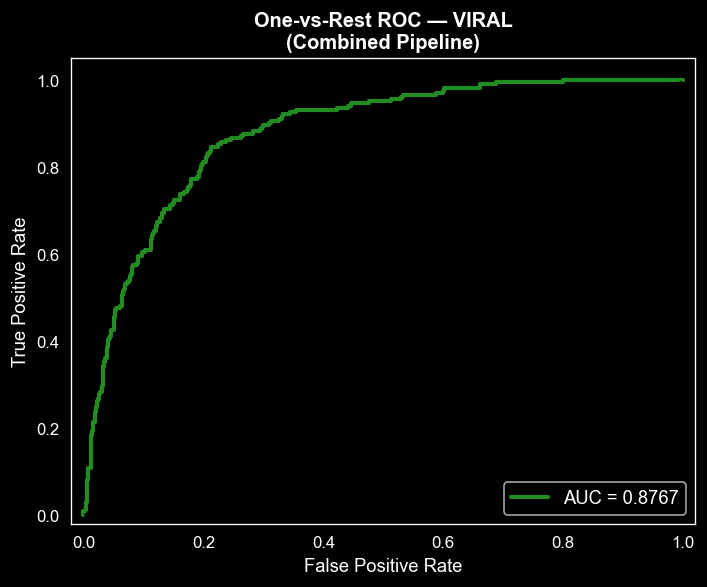

Saved: roc_curve_viral.png

AUC Summary:
  NORMAL      : 0.9982
  BACTERIAL   : 0.9113
  VIRAL       : 0.8767
  Macro avg   : 0.9287


In [23]:
prob_normal = 1.0 - p1_probs_all
prob_bacterial = p1_probs_all * (1.0 - p2_probs_all)
prob_viral = p1_probs_all * p2_probs_all
prob_matrix = np.column_stack([prob_normal, prob_bacterial, prob_viral])
y_bin = label_binarize(y_true, classes=[0, 1, 2])

colors = ["steelblue", "darkorange", "forestgreen"]
roc_results = {}

for i, (cls_name, color) in enumerate(zip(CLASS_NAMES, colors)):
    plt.figure(figsize=(6, 5))

    fpr, tpr, _ = roc_curve(y_bin[:, i], prob_matrix[:, i])
    roc_auc = auc(fpr, tpr)
    roc_results[cls_name] = roc_auc

    plt.plot(fpr, tpr, color=color, lw=2.5, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
    plt.xlim([-0.02, 1.02])
    plt.ylim([-0.02, 1.05])
    plt.grid(False)
    plt.xlabel("False Positive Rate", fontsize=11)
    plt.ylabel("True Positive Rate", fontsize=11)
    plt.title(
        f"One-vs-Rest ROC — {cls_name}\n(Combined Pipeline)",
        fontsize=12,
        fontweight="bold",
    )
    plt.legend(loc="lower right", fontsize=11)
    plt.tight_layout()

    filename = f"roc_curve_{cls_name.lower().replace(' ', '_')}.png"
    plt.savefig(filename, bbox_inches="tight")
    plt.show()
    print(f"Saved: {filename}")

print("\nAUC Summary:")
for cls_name, roc_auc in roc_results.items():
    print(f"  {cls_name:12s}: {roc_auc:.4f}")
macro_auc = np.mean(list(roc_results.values()))
print(f"  {'Macro avg':12s}: {macro_auc:.4f}")

## 7. Summary Dashboard

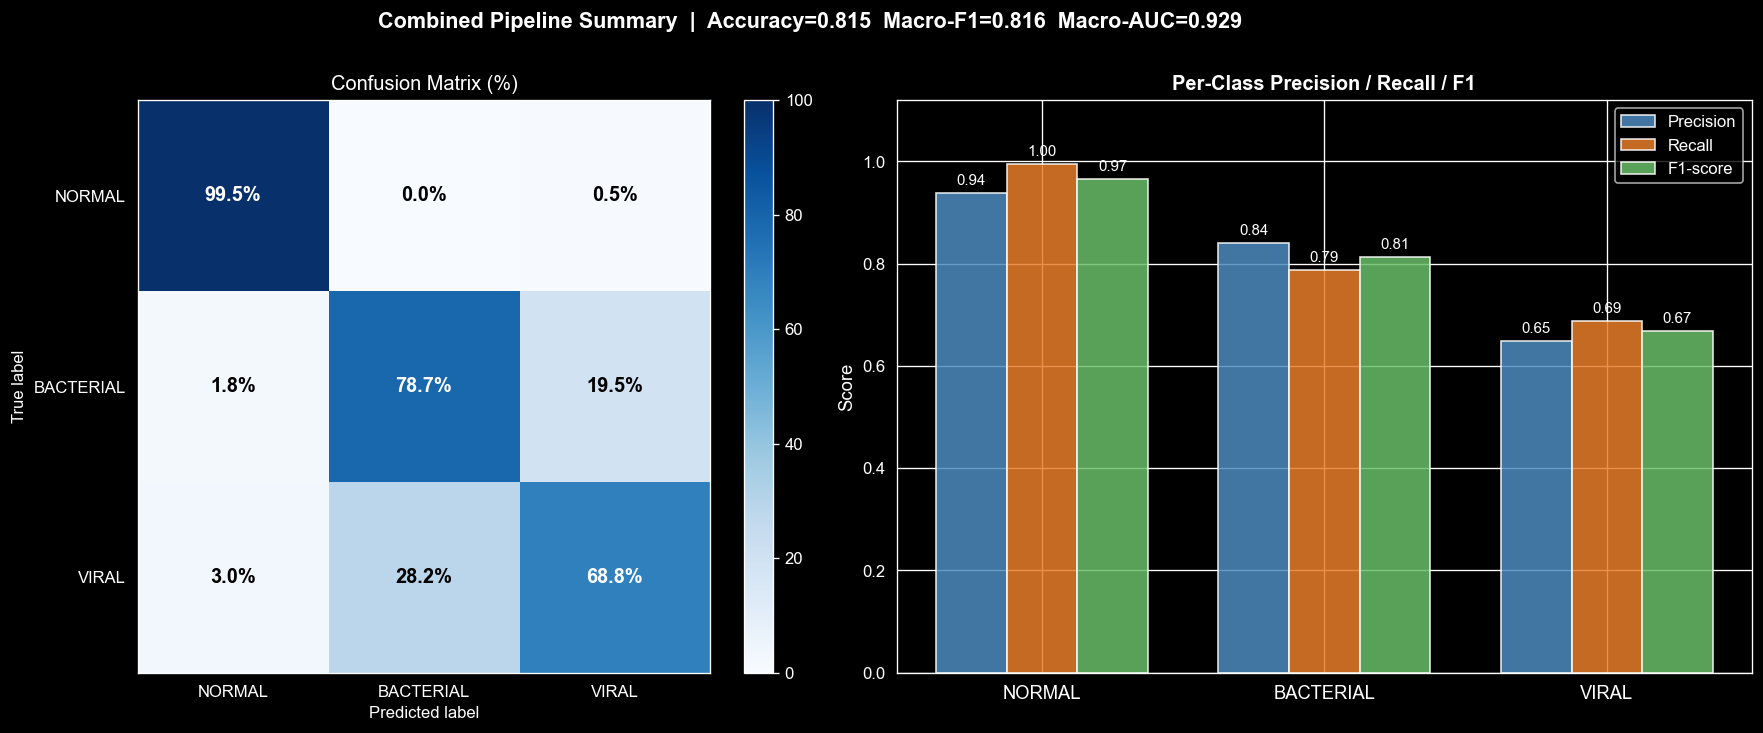

Saved: dashboard_combined.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: Confusion matrix (normalised) ────────────────────────────────────
cm_norm_pct = cm_norm * 100
im = axes[0].imshow(cm_norm_pct, interpolation="nearest", cmap="Blues", vmin=0, vmax=100)
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
axes[0].set(xticks=range(3), yticks=range(3),
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ylabel="True label", xlabel="Predicted label",
            title="Confusion Matrix (%)")
for i in range(3):
    for j in range(3):
        axes[0].text(j, i, f"{cm_norm_pct[i,j]:.1f}%",
                     ha="center", va="center",
                     color="white" if cm_norm_pct[i,j] > 50 else "black",
                     fontsize=12, fontweight="bold")

# ── Right: Per-class metrics bar chart ─────────────────────────────────────
report = classification_report(y_true, y_pred, target_names=CLASS_NAMES,
                               output_dict=True, zero_division=0)

metric_keys = ["precision", "recall", "f1-score"]
x = np.arange(len(CLASS_NAMES))
width = 0.25
bar_colors = ["#4C8CBF", "#E87D2A", "#6ABF69"]

for k, (metric, color) in enumerate(zip(metric_keys, bar_colors)):
    vals = [report[cls][metric] for cls in CLASS_NAMES]
    bars = axes[1].bar(x + k * width, vals, width, label=metric.capitalize(), color=color, alpha=0.85)
    for bar, val in zip(bars, vals):
        axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                     f"{val:.2f}", ha="center", va="bottom", fontsize=9)

axes[1].set_xticks(x + width)
axes[1].set_xticklabels(CLASS_NAMES, fontsize=11)
axes[1].set_ylim(0, 1.12)
axes[1].set_ylabel("Score", fontsize=11)
axes[1].set_title("Per-Class Precision / Recall / F1", fontsize=12, fontweight="bold")
axes[1].legend(fontsize=10)
axes[0].grid(False)


# Overall title with key numbers
fig.suptitle(
    f"Combined Pipeline Summary  |  Accuracy={acc:.3f}  Macro-F1={f1:.3f}  Macro-AUC={macro_auc:.3f}",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("dashboard_combined.png", bbox_inches="tight")
plt.show()
print("Saved: dashboard_combined.png")

## 8. Error Analysis (optional)

Show where the pipeline makes the most mistakes and identify the dominant error pattern.

In [21]:
error_mask = y_pred != y_true
errors = pd.DataFrame({
    "true_label" : [label_map[l] for l in y_true[error_mask]],
    "pred_label" : [label_map[l] for l in y_pred[error_mask]],
    "p1_prob"    : p1_probs_all[error_mask].round(4),
    "p2_prob"    : p2_probs_all[error_mask].round(4),
})

print(f"Total errors: {error_mask.sum()} / {len(y_true)}  ({error_mask.mean()*100:.1f}%)")
print()
print("Error breakdown (true → predicted):")
print(
    errors.groupby(["true_label", "pred_label"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .to_string(index=False)
)

# --- Phase-level breakdown ---
# Phase 1 errors: predicting NORMAL for a pneumonia sample, or vice versa
p1_true   = (y_true > 0).astype(int)          # 0=NORMAL, 1=PNEUMONIA
p1_pred   = (y_pred > 0).astype(int)
p1_errors = (p1_pred != p1_true).sum()
print(f"\nPhase 1 (Normal vs Pneumonia) errors  : {p1_errors} ({p1_errors/len(y_true)*100:.1f}%)")

# Phase 2 errors: among true pneumonia samples, wrong subtype
pneumonia_mask  = y_true > 0
p2_true_sub     = y_true[pneumonia_mask] - 1   # 0=BACTERIAL, 1=VIRAL
p2_pred_sub     = y_pred[pneumonia_mask] - 1
# Only count samples where Phase 1 was correct (predicted as pneumonia)
p1_correct_mask = p1_pred[pneumonia_mask] == 1
p2_errors       = (p2_pred_sub[p1_correct_mask] != p2_true_sub[p1_correct_mask]).sum()
p2_total        = p1_correct_mask.sum()
print(f"Phase 2 (Bacterial vs Viral) errors   : {p2_errors} / {p2_total} ({p2_errors/max(p2_total,1)*100:.1f}%)")

Total errors: 145 / 783  (18.5%)

Error breakdown (true → predicted):
true_label pred_label  count
 BACTERIAL      VIRAL     74
     VIRAL  BACTERIAL     57
 BACTERIAL     NORMAL      7
     VIRAL     NORMAL      6
    NORMAL      VIRAL      1

Phase 1 (Normal vs Pneumonia) errors  : 14 (1.8%)
Phase 2 (Bacterial vs Viral) errors   : 131 / 569 (23.0%)
